# Student Performance in Exams EDA

**Dataset:** [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977) - Kaggle  
**Rows:** 1,000 &nbsp;|&nbsp; **Columns:** 8

### Objective
Understand how demographic and socioeconomic factors (gender, race/ethnicity, parental education, lunch type, and test preparation) affect student scores in math, reading, and writing.

---

### Table of Contents
1. [Data Loading & Setup](#1)
2. [Data Quality Checks](#2)
3. [Feature Engineering](#3)
4. [Univariate Analysis](#4)
5. [Bivariate & Multivariate Analysis](#5)
6. [Outlier Detection](#6)
7. [Key Takeaways](#7)

---
## 1. Data Loading & Setup <a id='1'></a>

In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Prevent description columns from being cropped in meta_df
pd.set_option('display.max_colwidth', None)

In [67]:
df = pd.read_csv('../data/raw/StudentsPerformance.csv')

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')

print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 8)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


---
## 2. Data Quality Checks <a id='2'></a>

### 2.1. Quick Checkup

In [68]:
# Column Profile
meta = []

for col in df.columns:
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    unique = df[col].nunique()
    
    if pd.api.types.is_numeric_dtype(df[col]):
        desc = f'Range {df[col].min():.0f} - {df[col].max():.0f}'
    else:
        values = sorted(df[col].dropna().unique())
        desc = f'{len(values)} categories: {values}'
    
    meta.append({
        'Column': f'`{col}`',
        'Type': str(dtype),
        'Non-Null': non_null,
        'Unique': unique,
        'Description': desc
    })

meta_df = pd.DataFrame(meta)
meta_df

,Column,Type,Non-Null,Unique,Description
0,`gender`,str,1000,2,"2 categories: ['female', 'male']"
1,`race_ethnicity`,str,1000,5,"5 categories: ['group A', 'group B', 'group C', 'group D', 'group E']"
2,`parental_level_of_education`,str,1000,6,"6 categories: [""associate's degree"", ""bachelor's degree"", 'high school', ""master's degree"", 'some college', 'some high school']"
3,`lunch`,str,1000,2,"2 categories: ['free/reduced', 'standard']"
4,`test_preparation_course`,str,1000,2,"2 categories: ['completed', 'none']"
5,`math_score`,int64,1000,81,Range 0 - 100
6,`reading_score`,int64,1000,72,Range 17 - 100
7,`writing_score`,int64,1000,77,Range 10 - 100


### 2.2. Specific Checkup

In [69]:
# Missing Values
missing = df.isna().sum()
print('Missing values:\n', missing[missing > 0] if missing.any() else 'None, dataset is complete.')

Missing values:
 None, dataset is complete.


In [70]:
# Duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

Duplicate rows: 0


In [71]:
# Null and Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [72]:
# Unique Values
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [73]:
# Sanity Check: Numeric Columns
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Observations:**
- There is no impossible values (e.g., score > 100, negative score), all score columns have min ≥ 0 and max ≤ 100, confirming values stay within the valid test score range.
- Each score counts match expected row count

In [74]:
# Sanity Check: Categorical Columns

# Define expected valid values for each categorical column
expected_categories = {
    'gender': ['female', 'male'],
    'race_ethnicity': ['group A', 'group B', 'group C', 'group D', 'group E'],
    'parental_level_of_education': ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school'],
    'lunch': ['free/reduced', 'standard'],
    'test_preparation_course': ['completed', 'none']
}

# 1. Check for unexpected values
print('--- Unexpected Value Check ---')
for col, valid_values in expected_categories.items():
    unexpected = df[~df[col].isin(valid_values)]
    if not unexpected.empty:
        print(f"  {col}: unexpected values -> {sorted(unexpected[col].unique())}")
    else:
        print(f'  {col}: all values valid')

# 2. Check for empty strings / whitespace-only values
print('\n--- Empty / Whitespace Check ---')
for col in expected_categories.keys():
    empty_count = (df[col].astype(str).str.strip() == '').sum()
    if empty_count > 0:
        print(f"  {col}: {empty_count} empty/whitespace values")
    else:
        print(f"  {col}: no empty/whitespace values")

# 3. Check for common placeholder values
print('\n--- Placeholder Check ---')
placeholders = ['N/A', 'na', 'unknown', 'Unknown', '-', '?', 'NULL', 'null', 'None']
for col in expected_categories.keys():
    mask = df[col].isin(placeholders)
    if mask.any():
        print(f"  {col}: placeholders found -> {sorted(df.loc[mask, col].unique())}")
    else:
        print(f"  {col}: no placeholder values")

# 4. Check cardinality matches expectations
print('\n--- Cardinality Check ---')
for col, valid_values in expected_categories.items():
    actual = df[col].nunique()
    expected = len(valid_values)
    if actual != expected:
        print(f"  {col}: expected {expected} categories, got {actual}")
    else:
        print(f"  {col}: {actual} categories (as expected)")


--- Unexpected Value Check ---
  gender: all values valid
  race_ethnicity: all values valid
  parental_level_of_education: all values valid
  lunch: all values valid
  test_preparation_course: all values valid

--- Empty / Whitespace Check ---
  gender: no empty/whitespace values
  race_ethnicity: no empty/whitespace values
  parental_level_of_education: no empty/whitespace values
  lunch: no empty/whitespace values
  test_preparation_course: no empty/whitespace values

--- Placeholder Check ---
  gender: no placeholder values
  race_ethnicity: no placeholder values
  parental_level_of_education: no placeholder values
  lunch: no placeholder values
  test_preparation_course: no placeholder values

--- Cardinality Check ---
  gender: 2 categories (as expected)
  race_ethnicity: 5 categories (as expected)
  parental_level_of_education: 6 categories (as expected)
  lunch: 2 categories (as expected)
  test_preparation_course: 2 categories (as expected)


**Observations:**
- All categorical columns contain only expected values, no typos or invalid categories detected.
- No empty strings, whitespace-only entries, or common placeholder values found.
- Cardinality matches expectations for every categorical column.

---
## 3. Feature Engineering <a id='3'></a>

In [75]:
# Aggregate scores
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = (df['total_score'] / 3).round(2)

# Perfect scores and very low scorers
subjects = {'math_score': 'Math', 'reading_score': 'Reading', 'writing_score': 'Writing'}

print('Students with full marks (100):')
for col, name in subjects.items():
    print(f'  {name}: {(df[col] == 100).sum()}')

print('\nStudents scoring ≤ 20:')
for col, name in subjects.items():
    print(f'  {name}: {(df[col] <= 20).sum()}')

Students with full marks (100):
  Math: 7
  Reading: 17
  Writing: 14

Students scoring ≤ 20:
  Math: 4
  Reading: 1
  Writing: 3


**Observations:**
- Reading has the most perfect scores; Math has the most very low scorers.
- Students underperform most in math at both extremes.

In [76]:
df[['math_score', 'reading_score', 'writing_score', 'total_score', 'average_score']].head()

,math_score,reading_score,writing_score,total_score,average_score
0,72,72,74,218,72.67
1,69,90,88,247,82.33
2,90,95,93,278,92.67
3,47,57,44,148,49.33
4,76,78,75,229,76.33


---
## 4. Univariate Analysis <a id='4'></a>

### 4.1. Score Distributions

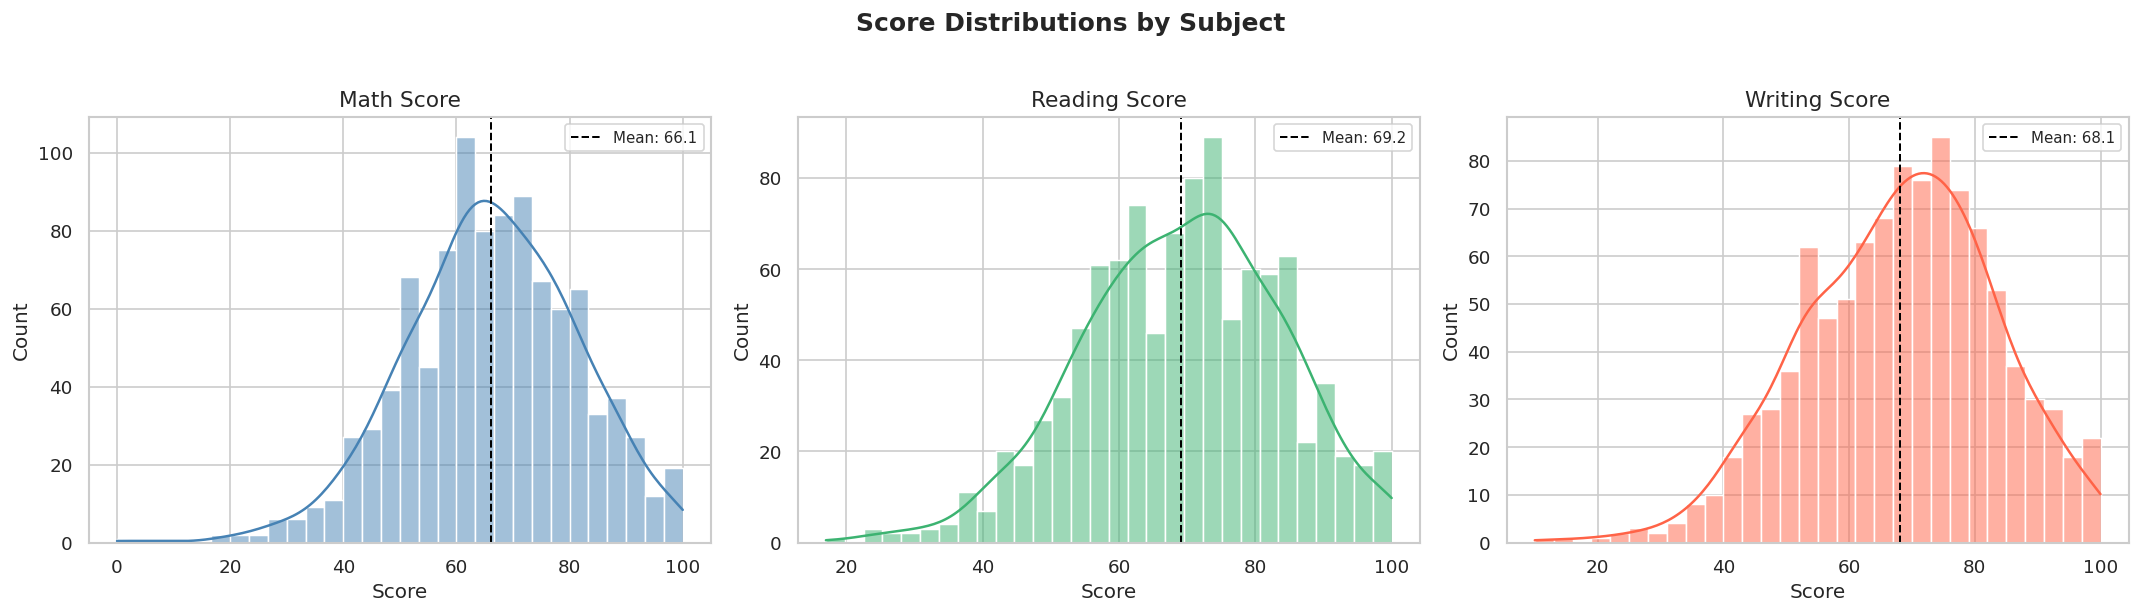

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
score_cols = ['math_score', 'reading_score', 'writing_score']
colors = ['steelblue', 'mediumseagreen', 'tomato']

for ax, col, color in zip(axes, score_cols, colors):
    sns.histplot(df[col], kde=True, color=color, ax=ax, bins=30)
    ax.set_title(col.replace('_', ' ').title(), fontsize=13)
    ax.set_xlabel('Score')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean: {df[col].mean():.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Score Distributions by Subject', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- All three subjects show approximately normal distributions.
- Math has the widest spread and lowest mean, reading and writing are more tightly clustered.

### 4.2. Categorical Variable Distributions

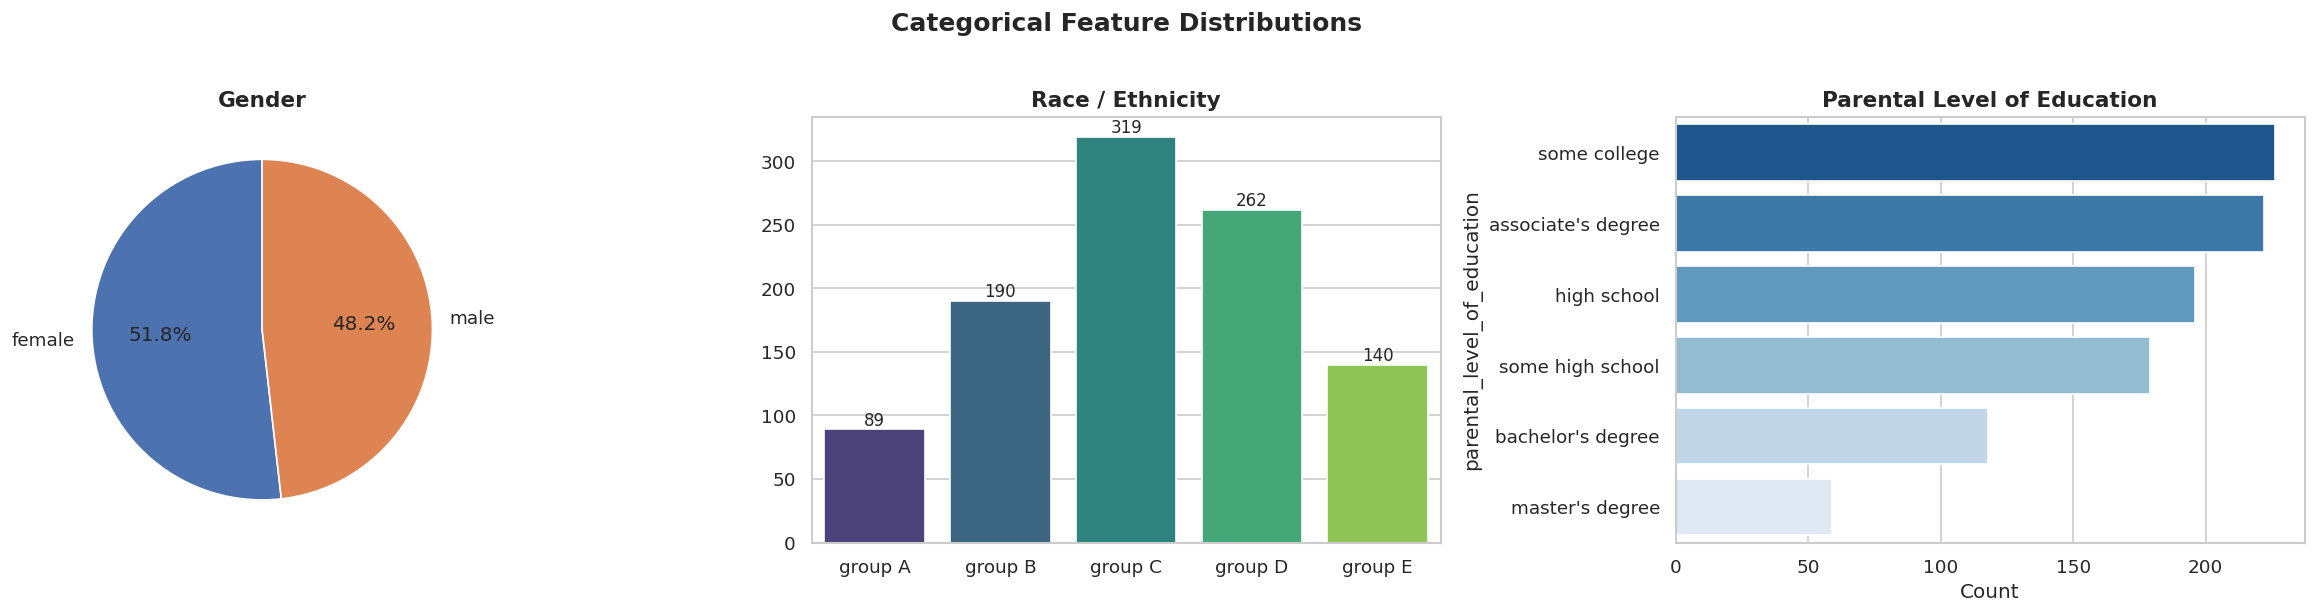

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gender
gender_counts = df['gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0].set_title('Gender', fontsize=13, fontweight='bold')

# Race/Ethnicity
eth_counts = df['race_ethnicity'].value_counts().sort_index()
sns.barplot(x=eth_counts.index, y=eth_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title('Race / Ethnicity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=10)

# Parental Education
edu_counts = df['parental_level_of_education'].value_counts()
sns.barplot(x=edu_counts.values, y=edu_counts.index, ax=axes[2], palette='Blues_r')
axes[2].set_title('Parental Level of Education', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Gender is nearly balanced (Female 51.8% / Male 48.2%).
- Group C is the largest ethnicity group; Group A the smallest.
- Some college is the most common parental education level.

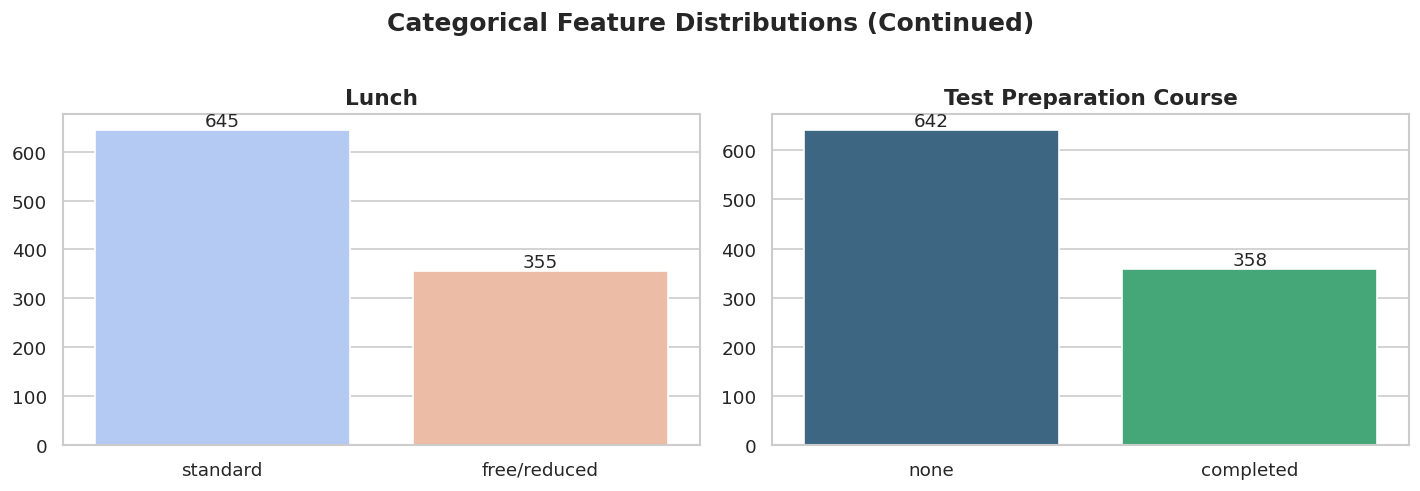

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Lunch
lunch_counts = df['lunch'].value_counts()
sns.barplot(x=lunch_counts.index, y=lunch_counts.values, ax=axes[0], palette='coolwarm')
axes[0].set_title('Lunch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11)

# Test Preparation Course
prep_counts = df['test_preparation_course'].value_counts()
sns.barplot(x=prep_counts.index, y=prep_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title('Test Preparation Course', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=11)

plt.suptitle('Categorical Feature Distributions (Continued)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Most students receive standard lunch.
- The majority of students have not completed a test prep course.

---
## 5. Bivariate & Multivariate Analysis <a id='5'></a>

### 5.1. Effect of Gender on Scores

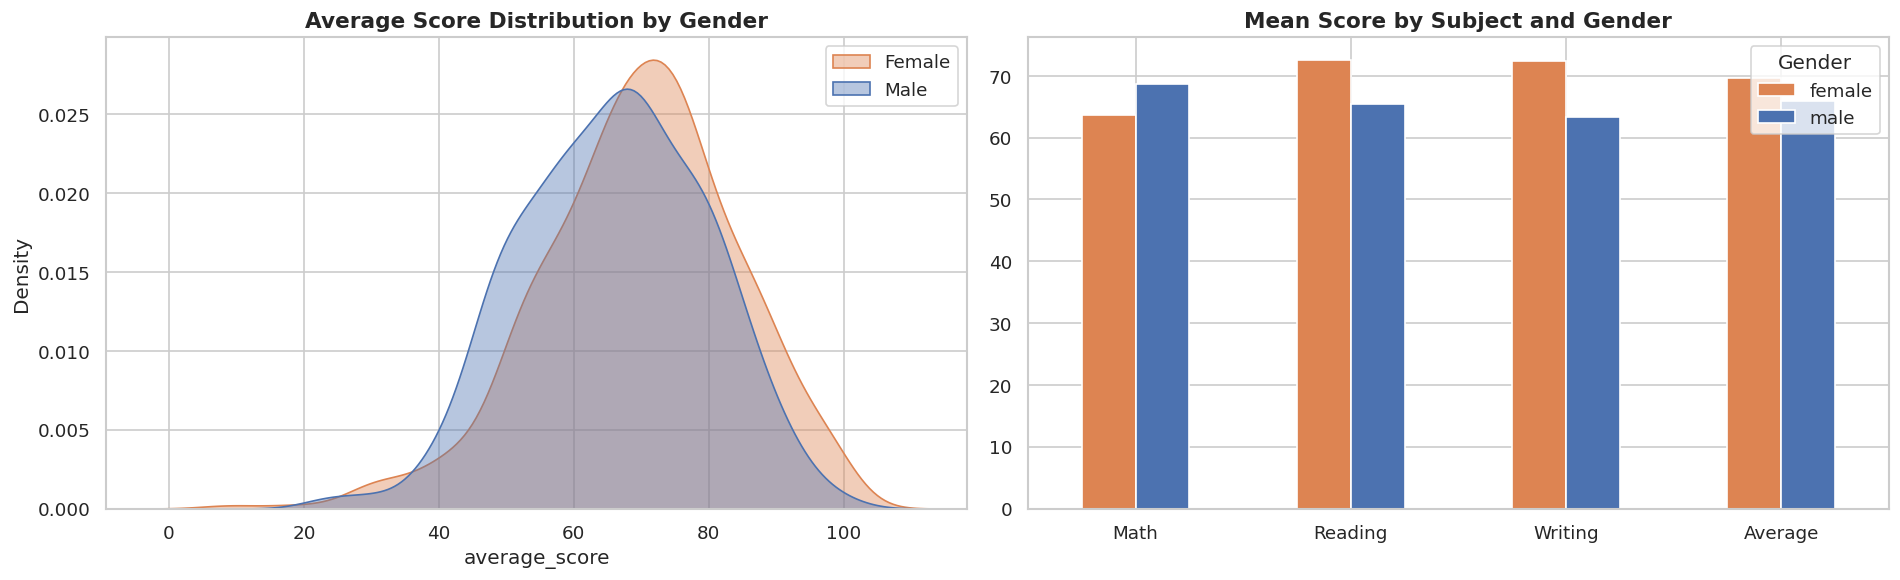

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of average score by gender
for gender, color in zip(['female', 'male'], ['#DD8452', '#4C72B0']):
    sns.kdeplot(df[df['gender'] == gender]['average_score'], label=gender.title(),
                fill=True, alpha=0.4, ax=axes[0], color=color)
axes[0].set_title('Average Score Distribution by Gender', fontsize=13, fontweight='bold')
axes[0].legend()

# Mean scores by gender
gender_means = df.groupby('gender')[['math_score', 'reading_score', 'writing_score', 'average_score']].mean().T
gender_means.plot(kind='bar', ax=axes[1], color=['#DD8452', '#4C72B0'], edgecolor='white')
axes[1].set_title('Mean Score by Subject and Gender', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_xticklabels([c.replace('_score', '').title() for c in gender_means.index], rotation=0)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

**Observations:**
- Females have a higher overall average and outperform males in reading and writing.
- Males score higher in math on average.

### 5.2. Effect of Race/Ethnicity on Scores

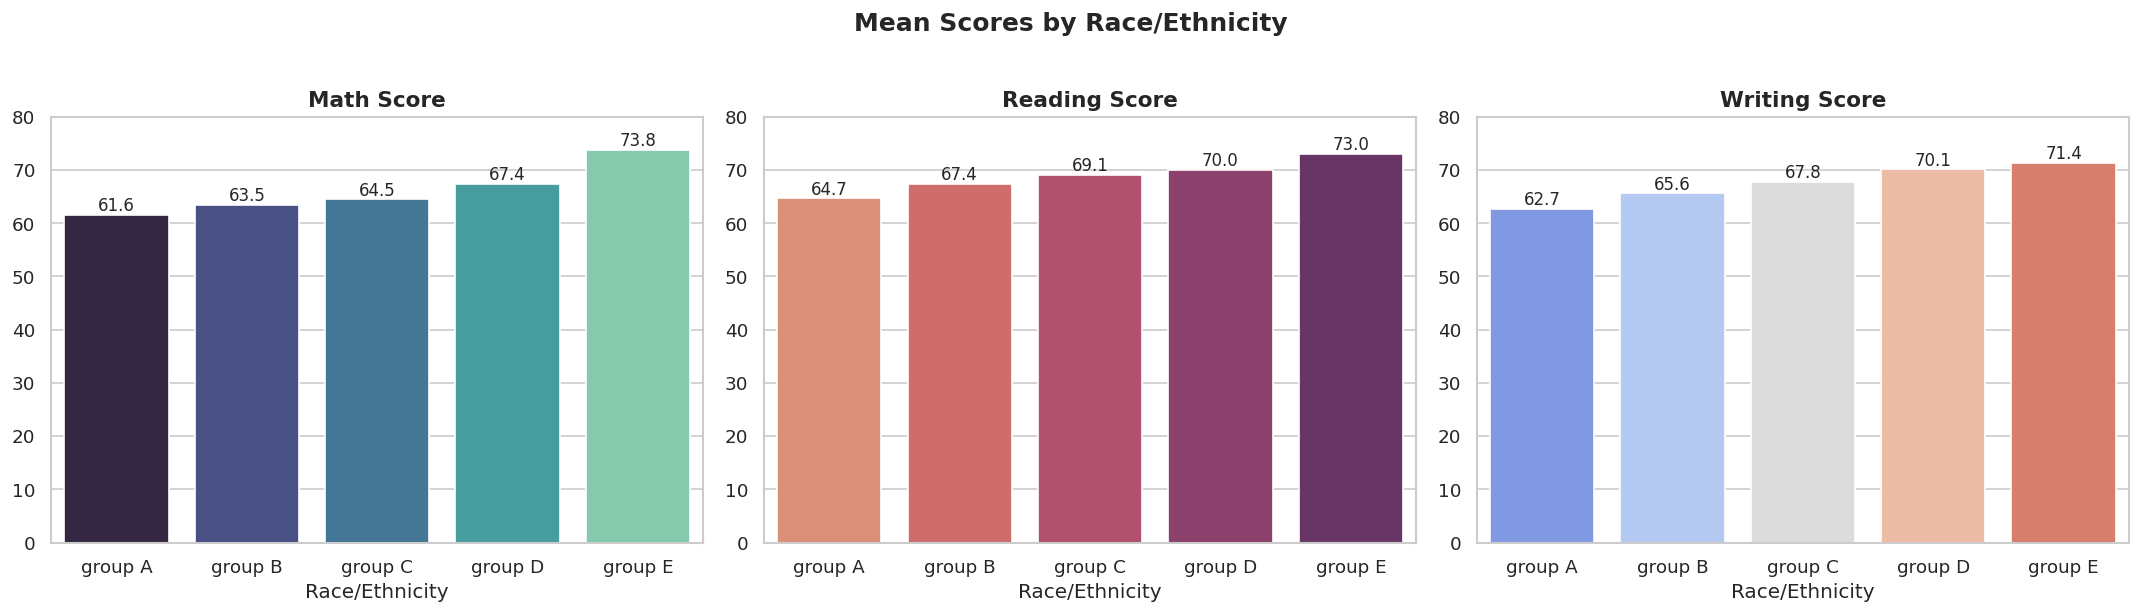

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palettes = ['mako', 'flare', 'coolwarm']

for ax, col, pal in zip(axes, ['math_score', 'reading_score', 'writing_score'], palettes):
    group_means = df.groupby('race_ethnicity')[col].mean().sort_index()
    sns.barplot(x=group_means.index, y=group_means.values, palette=pal, ax=ax)
    ax.set_title(col.replace('_score', '').title() + ' Score', fontsize=13, fontweight='bold')
    ax.set_xlabel('Race/Ethnicity')
    ax.set_ylim(0, 80)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=10)

plt.suptitle('Mean Scores by Race/Ethnicity', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Group E consistently scores the highest across all subjects.
- Group A consistently scores the lowest.
- There is a clear upward trend from Group A -> E.

### 5.3. Effect of Parental Education on Scores

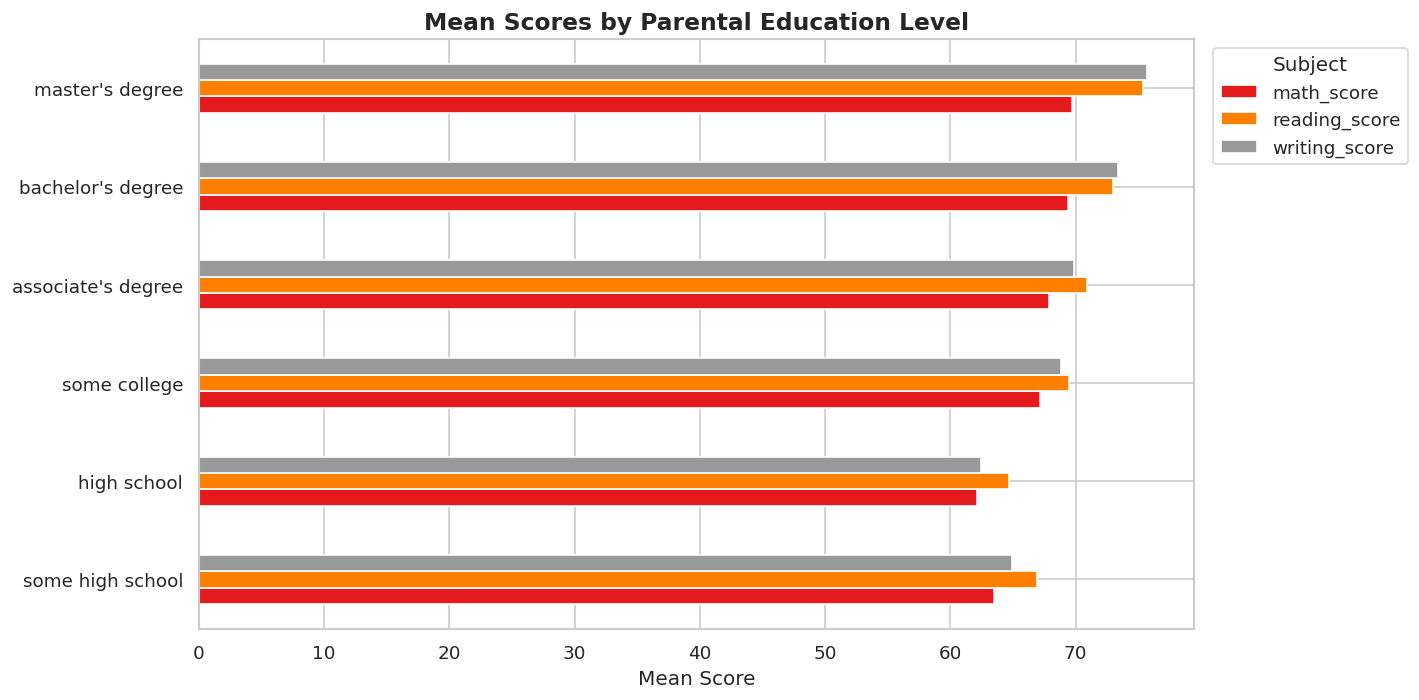

In [82]:
edu_order = [
    'some high school', 'high school', 'some college',
    "associate's degree", "bachelor's degree", "master's degree"
]

edu_means = (
    df.groupby('parental_level_of_education')[['math_score', 'reading_score', 'writing_score']]
    .mean()
    .reindex(edu_order)
)

edu_means.plot(kind='barh', figsize=(12, 6), colormap='Set1', edgecolor='white')
plt.title('Mean Scores by Parental Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Mean Score')
plt.ylabel('')
plt.legend(title='Subject', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observations:**
- Students with parents holding a master's or bachelor's degree tend to score higher.

### 5.4. Effect of Lunch Type and Test Preparation on Scores

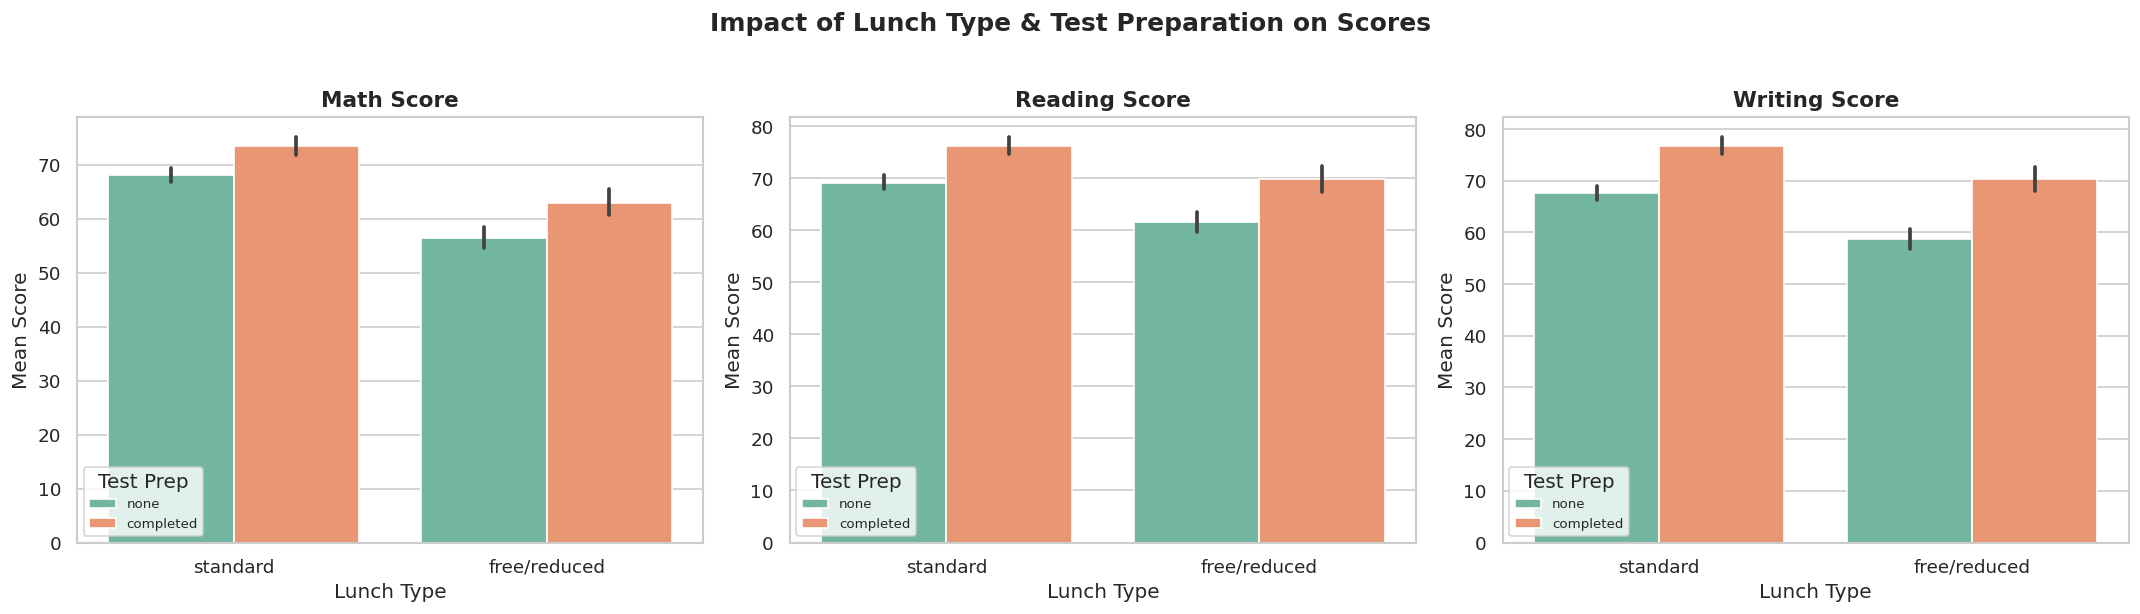

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['math_score', 'reading_score', 'writing_score']):
    sns.barplot(
        data=df, x='lunch', y=col, hue='test_preparation_course',
        palette='Set2', ax=ax
    )
    ax.set_title(col.replace('_score', '').title() + ' Score', fontsize=13, fontweight='bold')
    ax.set_xlabel('Lunch Type')
    ax.set_ylabel('Mean Score')
    ax.legend(title='Test Prep', fontsize=8)

plt.suptitle('Impact of Lunch Type & Test Preparation on Scores', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Students with standard lunch consistently outperform those on free/reduced lunch.
- Completing the test preparation course improves scores across all subjects and lunch types.

### 5.5. Cross-Score Relationships

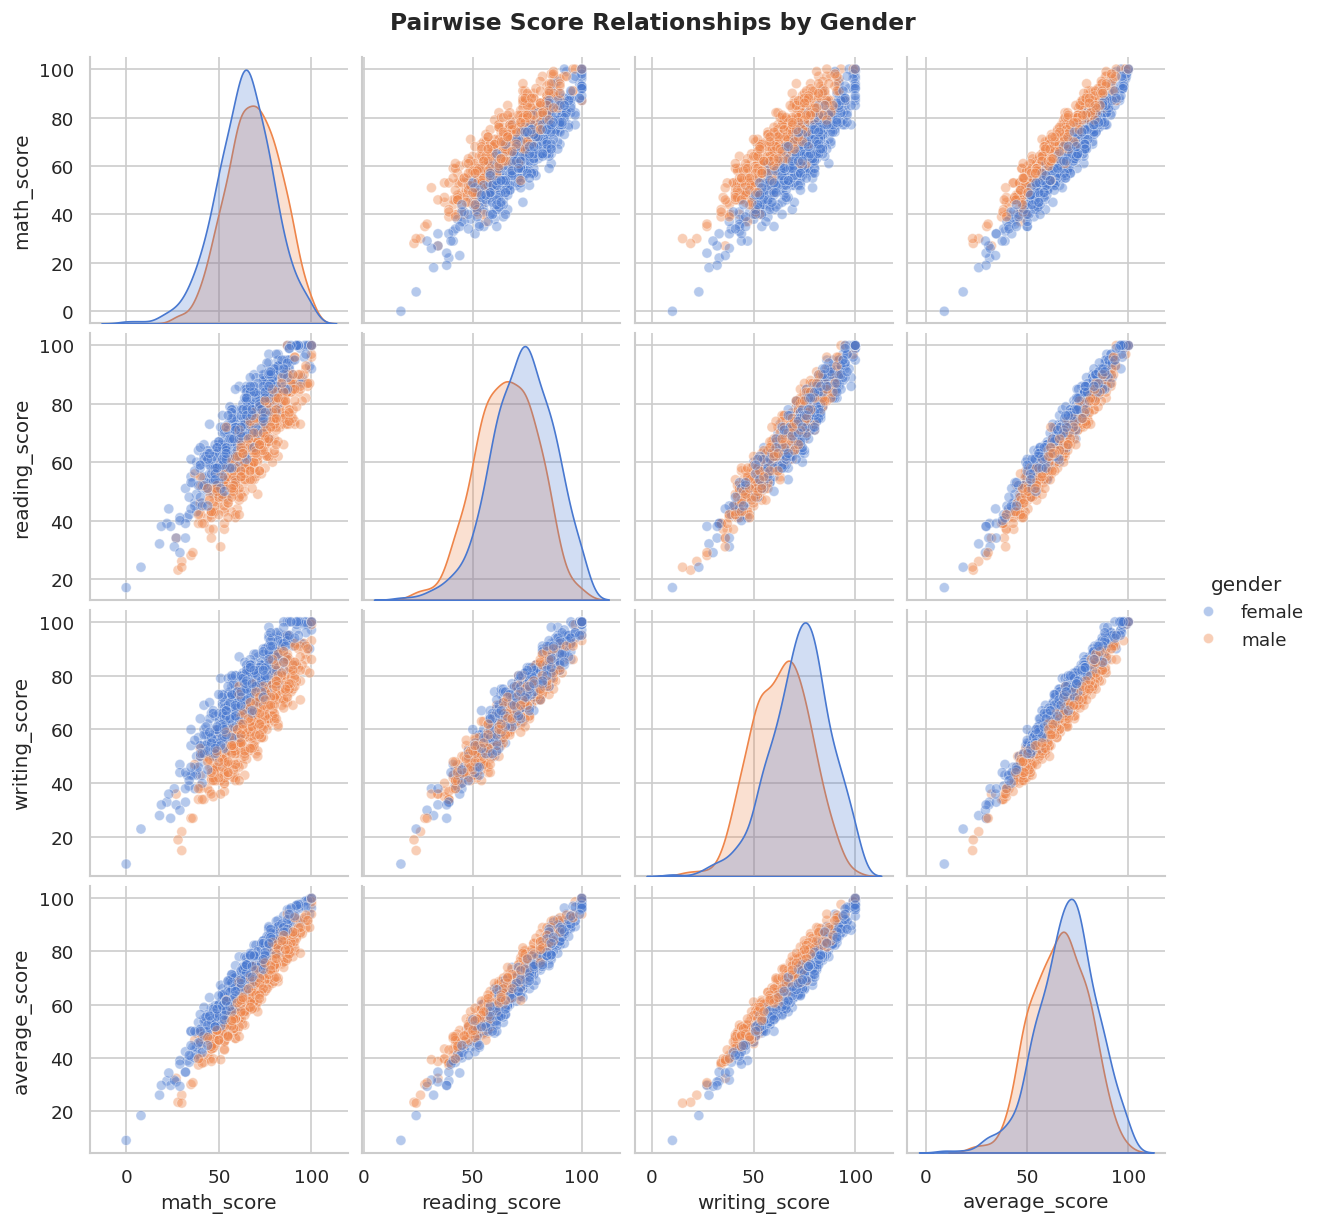

In [84]:
sns.pairplot(
    df[['math_score', 'reading_score', 'writing_score', 'average_score', 'gender']],
    hue='gender', plot_kws={'alpha': 0.4}, diag_kind='kde'
)
plt.suptitle('Pairwise Score Relationships by Gender', y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Observations:**
- All three subject scores are strongly positively correlated.
- Students who perform well in one subject tend to perform well in all.
- Gender clusters are visible but overlapping, indicating subject performance is more individual than gender-determined.

### 5.6. Correlation Heatmap

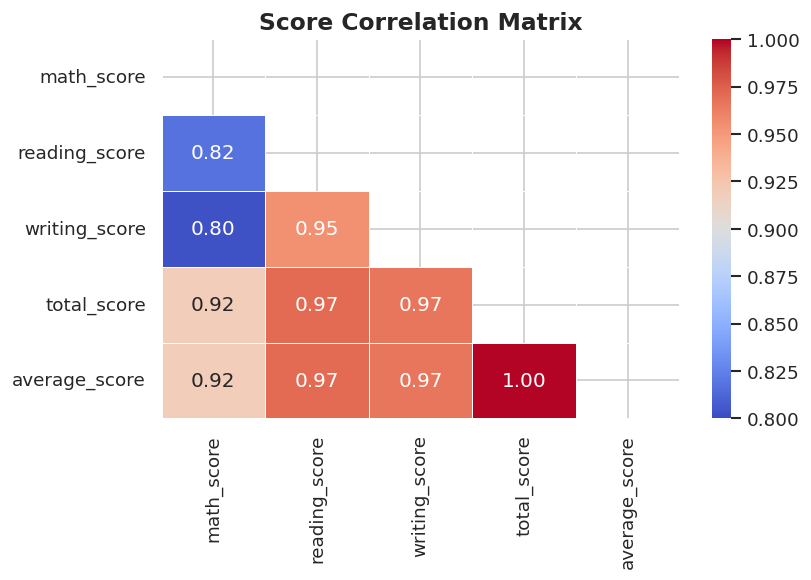

In [85]:
plt.figure(figsize=(7, 5))
corr = df[['math_score', 'reading_score', 'writing_score', 'total_score', 'average_score']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=0.8, vmax=1)
plt.title('Score Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- All score correlations exceed 0.80, indicating very strong positive relationships.
- Reading and writing are the most highly correlated pair (≈ 0.95).
- Total and average scores are perfectly correlated with each other and strongly correlated with individual subjects, as expected by definition.

---
## 6. Outlier Detection <a id='6'></a>

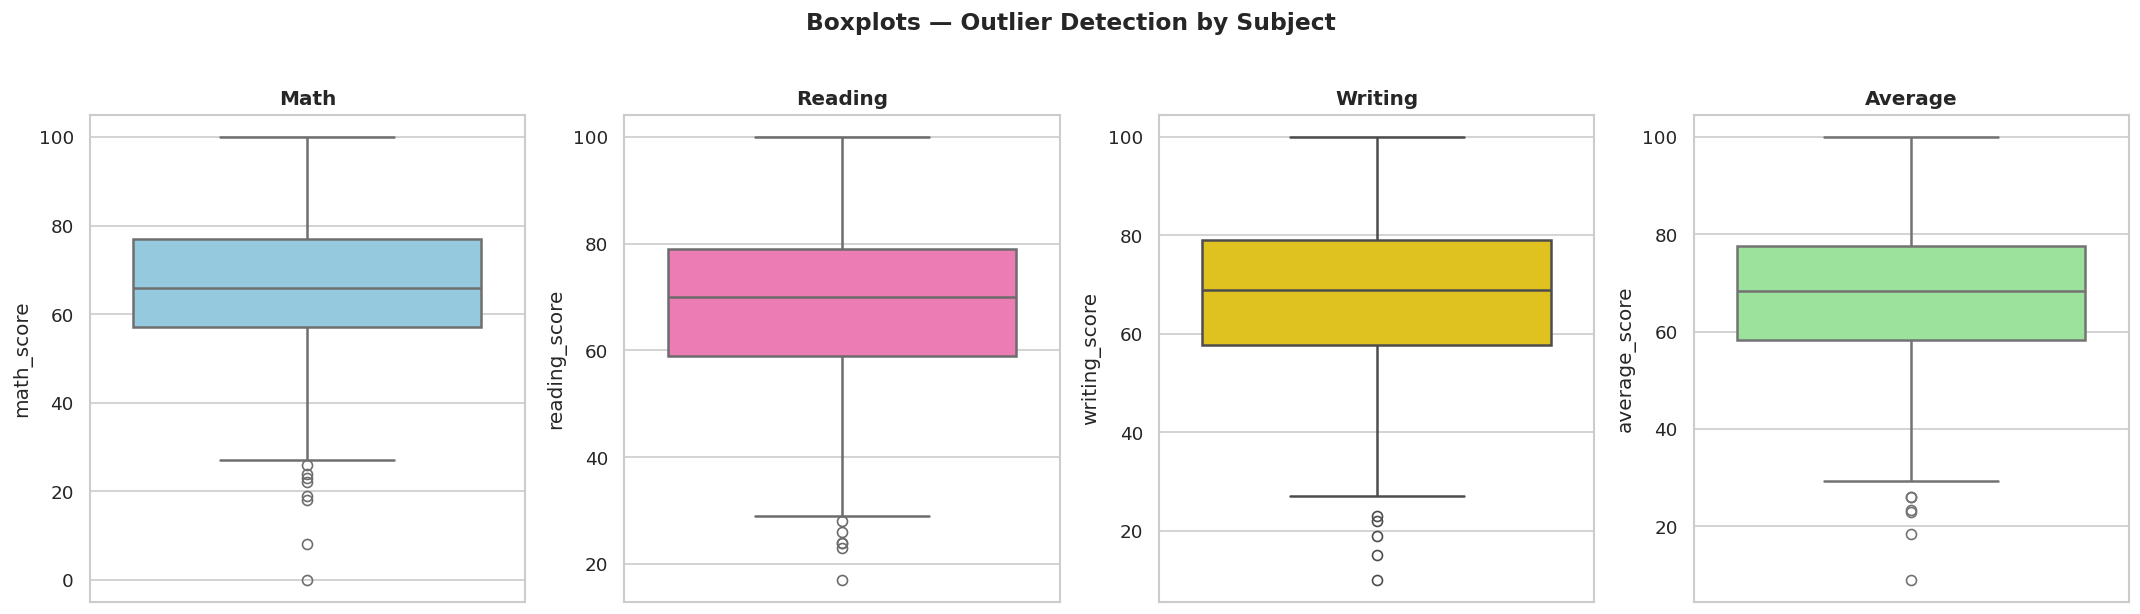

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
cols_to_plot = ['math_score', 'reading_score', 'writing_score', 'average_score']
colors = ['skyblue', 'hotpink', 'gold', 'lightgreen']

for ax, col, color in zip(axes, cols_to_plot, colors):
    sns.boxplot(y=df[col], color=color, ax=ax, linewidth=1.5)
    ax.set_title(col.replace('_score', '').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Boxplots — Outlier Detection by Subject', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [64]:
# IQR-based outlier summary
print('Outlier count per column (IQR method):')
for col in ['math_score', 'reading_score', 'writing_score']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f'  {col}: {len(outliers)} outliers')

Outlier count per column (IQR method):
  math_score: 8 outliers
  reading_score: 6 outliers
  writing_score: 5 outliers


In [63]:
# Deeper outlier analysis: who are the outliers?

# Collect all outlier indices across the three subjects
outlier_indices = set()
for col in ['math_score', 'reading_score', 'writing_score']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_indices.update(df[mask].index.tolist())

outlier_df = df.loc[list(outlier_indices)].copy()
outlier_df['outlier_count'] = 0
for col in ['math_score', 'reading_score', 'writing_score']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_df['outlier_count'] += ((outlier_df[col] < lower) | (outlier_df[col] > upper)).astype(int)

print(f'Total unique students flagged as outliers in at least one subject: {len(outlier_df)}')
print('\nOutlier rows:')
display(outlier_df[['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
                     'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'outlier_count']])

# Check clustering by categorical variables
print('\n--- Outlier clustering by categorical variables ---')
for cat_col in ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']:
    outlier_counts = outlier_df[cat_col].value_counts()
    total_counts = df[cat_col].value_counts()
    pct = (outlier_counts / total_counts * 100).fillna(0).round(1)
    print(f'\n{cat_col}:')
    for cat in total_counts.index:
        print(f"  {cat}: {outlier_counts.get(cat, 0)} outlier students / {total_counts[cat]} total ({pct.get(cat, 0)}%)")


Total unique students flagged as outliers in at least one subject: 12

Outlier rows:


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,outlier_count
327,male,group A,some college,free/reduced,none,28,23,19,2
842,female,group B,high school,free/reduced,completed,23,44,36,1
76,male,group E,some high school,standard,none,30,26,22,2
17,female,group B,some high school,free/reduced,none,18,32,28,1
145,female,group C,some college,free/reduced,none,22,39,33,1
338,female,group B,some high school,free/reduced,none,24,38,27,1
466,female,group D,associate's degree,free/reduced,none,26,31,38,1
787,female,group B,some college,standard,none,19,38,32,1
980,female,group B,high school,free/reduced,none,8,24,23,3
211,male,group C,some college,free/reduced,none,35,28,27,1



--- Outlier clustering by categorical variables ---

gender:
  female: 8 outlier students / 518 total (1.5%)
  male: 4 outlier students / 482 total (0.8%)

race_ethnicity:
  group C: 3 outlier students / 319 total (0.9%)
  group D: 1 outlier students / 262 total (0.4%)
  group B: 6 outlier students / 190 total (3.2%)
  group E: 1 outlier students / 140 total (0.7%)
  group A: 1 outlier students / 89 total (1.1%)

parental_level_of_education:
  some college: 4 outlier students / 226 total (1.8%)
  associate's degree: 1 outlier students / 222 total (0.5%)
  high school: 3 outlier students / 196 total (1.5%)
  some high school: 4 outlier students / 179 total (2.2%)
  bachelor's degree: 0 outlier students / 118 total (0.0%)
  master's degree: 0 outlier students / 59 total (0.0%)

lunch:
  standard: 2 outlier students / 645 total (0.3%)
  free/reduced: 10 outlier students / 355 total (2.8%)

test_preparation_course:
  none: 11 outlier students / 642 total (1.7%)
  completed: 1 outlier stud

**Observations:**
- The number of outliers is minimal.
- Most outliers are low-end outliers in math (scores near 0), worth investigating for data entry errors or genuinely at-risk students.
- A small number of students are outliers in multiple subjects simultaneously, suggesting broad academic struggle rather than subject-specific issues.
- Outlier distribution across categorical variables roughly mirrors the overall dataset proportions, indicating no single demographic group is disproportionately flagged.

---
## 7. Key Takeaways <a id='7'></a>

| Factor | Finding |
|--------|---------|
| **Gender** | Females outperform males overall and in reading/writing; males score higher in math. |
| **Race/Ethnicity** | Scores increase monotonically from Group A to Group E across all subjects. |
| **Parental Education** | Higher parental education (master's / bachelor's) correlates with better student scores. |
| **Lunch Type** | Standard lunch students consistently outscore free/reduced lunch students (a proxy for socioeconomic status). |
| **Test Preparation** | Completing the prep course has a positive but modest effect on all three subjects. |
| **Score Correlation** | All three subject scores are highly correlated (r > 0.8), suggesting a common underlying academic ability. |
| **Outliers** | Very few; minor low-end outliers in math warrant investigation. |

**Overall Insights:**
- Socioeconomic status (lunch type and parental education) shows the strongest and most consistent relationship with student performance.
- Test preparation has a positive effect, but its impact is smaller than demographic and socioeconomic factors.
- Subject scores move together strongly, meaning students who struggle in one subject tend to struggle in all three, suggesting interventions should be holistic rather than subject-specific.